## 1. Loading & Cleaning the Data

In [5]:
import pandas as pd
import requests
import time
import os
from tqdm import tqdm

print("--- Phase 1: Loading & Cleaning ClinVar Data ---")
file_path = '/kaggle/input/datasets/competitiveracist/clinvar-tab-delimited/variant_summary.txt'

# Read the .txt file using tabs
df = pd.read_csv(file_path, sep='\t', low_memory=False)
df = df[df['Assembly'] == 'GRCh38']

# Drop missing VCF positions
df = df.dropna(subset=['ReferenceAlleleVCF', 'AlternateAlleleVCF', 'PositionVCF'])
df = df[df['PositionVCF'] != -1]

# Filter for SNPs only (Ensembl API breaks on massive indels)
df = df[
    (df['ReferenceAlleleVCF'].astype(str).str.len() == 1) &
    (df['AlternateAlleleVCF'].astype(str).str.len() == 1)
]

# Filter for clear Pathogenic or Benign cases (drops "Uncertain significance")
pathogenic_mask = df['ClinicalSignificance'].astype(str).str.contains('Pathogenic', case=False, na=False)
benign_mask = df['ClinicalSignificance'].astype(str).str.contains('Benign', case=False, na=False)
df = df[pathogenic_mask | benign_mask].copy()

# Create the clean binary target column
df['Target'] = df['ClinicalSignificance'].apply(lambda x: 1 if 'pathogenic' in str(x).lower() else 0)

print(f"Total clean SNP rows ready to process: {len(df)}")

--- Phase 1: Loading & Cleaning ClinVar Data ---
Total clean SNP rows ready to process: 1615872


In [ ]:
df.head()

## 2. The API Extraction Engine

In [ ]:
# none

## 3. The Checkpoint Scraping Loop

In [ ]:
import os
import requests
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

print("--- Phase 3: The Bulk-Batched Multi-Threaded Scraper ---")

# 1. THE GOLDEN RULE: Deduplication
# This instantly deletes hundreds of thousands of useless duplicate API pings
df_unique = df.drop_duplicates(subset=['Chromosome', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']).copy()
print(f"Removed duplicates. Unique mutations left to scrape: {len(df_unique)}")

# 2. PREPARE THE BATCHES
# Ensembl's maximum allowed limit for a POST request is 200 variants
BATCH_SIZE = 200 
batches = [df_unique.iloc[i:i + BATCH_SIZE] for i in range(0, len(df_unique), BATCH_SIZE)]
print(f"Divided into {len(batches)} batches of {BATCH_SIZE} variants.")

output_file = '/kaggle/working/massive_enriched_dataset.csv'
if not os.path.isfile(output_file):
    with open(output_file, 'w') as f:
        f.write("Variant_ID,gnomAD_AF,SIFT_Score,CADD_Score,Is_Nonsense,Is_Missense,Is_Synonymous,Is_Splice_Site,Is_Pathogenic\n")

# Resume logic: Read what we already have so we don't double-scrape
try:
    existing_df = pd.read_csv(output_file)
    completed_variants = set(existing_df['Variant_ID'].values)
    print(f"Found {len(completed_variants)} already scraped variants. Resuming...")
except pd.errors.EmptyDataError:
    completed_variants = set()

# 3. THE BULK WORKER FUNCTION
def process_batch(batch_df):
    server = "https://rest.ensembl.org"
    # Using the POST endpoint instead of GET
    ext = "/vep/human/region?af=1&CADD=1"
    headers = { "Content-Type": "application/json", "Accept": "application/json"}

    payload_variants = []
    metadata = {} # To remember which target maps to which variant

    for _, row in batch_df.iterrows():
        chrom = str(row['Chromosome']).replace('chr', '')
        pos = int(row['PositionVCF'])
        ref = row['ReferenceAlleleVCF']
        alt = row['AlternateAlleleVCF']
        target = row['Target']
        var_id = f"{chrom}:{pos}:{ref}:{alt}"

        if var_id in completed_variants:
            continue # Skip if we already saved this one

        # The Ensembl bulk string format requires the strand (usually 1)
        query_str = f"{chrom}:{pos}-{pos}:1/{alt}"
        payload_variants.append(query_str)
        metadata[query_str] = {"var_id": var_id, "target": target, "alt": alt}

    # If the whole batch was already scraped, return empty list
    if not payload_variants:
        return [] 

    results = []
    try:
        # Send all 200 variants in ONE network ping
        res = requests.post(server + ext, headers=headers, json={"variants": payload_variants}, timeout=30)
        if res.ok:
            data_list = res.json()
            
            # Loop through the massive response payload
            for data in data_list:
                q_str = data.get('input')
                if not q_str or q_str not in metadata: continue

                meta = metadata[q_str]
                alt_allele = meta["alt"]

                # Extract features exactly like before
                af, sift, cadd = 0.0, 0.05, 0.0
                nonsense, missense, syn, splice = 0, 0, 0, 0

                for colocated in data.get('colocated_variants', []):
                    freqs = colocated.get('frequencies', {}).get(alt_allele, {})
                    for key in ['gnomad', 'gnomade', 'gnomadg']:
                        if key in freqs:
                            af = float(freqs[key])
                            break
                    if af > 0.0: break

                sift_temp, sift_found = 1.0, False
                for t in data.get('transcript_consequences', []):
                    terms = t.get('consequence_terms', [])
                    if 'stop_gained' in terms: nonsense = 1
                    if 'missense_variant' in terms: missense = 1
                    if 'synonymous_variant' in terms: syn = 1
                    if any('splice' in term for term in terms): splice = 1

                    if 'sift_score' in t:
                        sift_found = True
                        if t['sift_score'] < sift_temp: sift_temp = t['sift_score']
                    if 'cadd_phred' in t and t['cadd_phred'] > cadd:
                        cadd = t['cadd_phred']

                if sift_found: sift = sift_temp

                # Format the final CSV string
                results.append(f"{meta['var_id']},{af},{sift},{cadd},{nonsense},{missense},{syn},{splice},{meta['target']}\n")
    except Exception as e:
        # If Ensembl completely crashes on a batch, we just pass and retry later
        pass 

    return results

# 4. THE THREAD POOL MANAGER
MAX_THREADS = 10 
buffer = []

print(f"Igniting Bulk API Scraper with {MAX_THREADS} threads. Hold on tight...")

with ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
    futures = [executor.submit(process_batch, batch) for batch in batches]
    
    # We use tqdm on the BATCHES, not individual rows.
    for future in tqdm(as_completed(futures), total=len(futures), desc="Bulk Scraping"):
        try:
            batch_results = future.result()
            buffer.extend(batch_results)
            
            # Checkpoint every ~1000 rows safely
            if len(buffer) >= 1000:
                with open(output_file, 'a') as f:
                    f.writelines(buffer)
                buffer = [] 
        except Exception:
            pass

if buffer:
    with open(output_file, 'a') as f:
        f.writelines(buffer)

print("🎉 BOOM! Bulk scraping complete. Dataset is fully loaded.")

In [ ]:
import shutil

print("🗜️ Compressing the massive dataset for easy download...")
# shutil.make_archive automatically adds the .zip extension to your base_name
shutil.make_archive(
    base_name='/kaggle/working/massive_dataset', 
    format='zip', 
    root_dir='/kaggle/working', 
    base_dir='massive_enriched_dataset.csv'
)
print("Zipped successfully! You are clear for takeoff.")

--- Phase 1: Loading & Sanity Checks ---
Total Variants Scraped: 447459

Class Balance (Should be close to 50/50):
Is_Pathogenic
0    69.497764
1    30.502236
Name: proportion, dtype: float64

Missing Values (Should be 0):
Variant_ID        0
gnomAD_AF         0
SIFT_Score        0
CADD_Score        0
Is_Nonsense       0
Is_Missense       0
Is_Synonymous     0
Is_Splice_Site    0
Is_Pathogenic     0
dtype: int64

--- Phase 2: Biological Feature Verification ---
API Timeouts (Defaults used): SIFT=323256, CADD=1940

--- Phase 3: Visualizing the Data ---


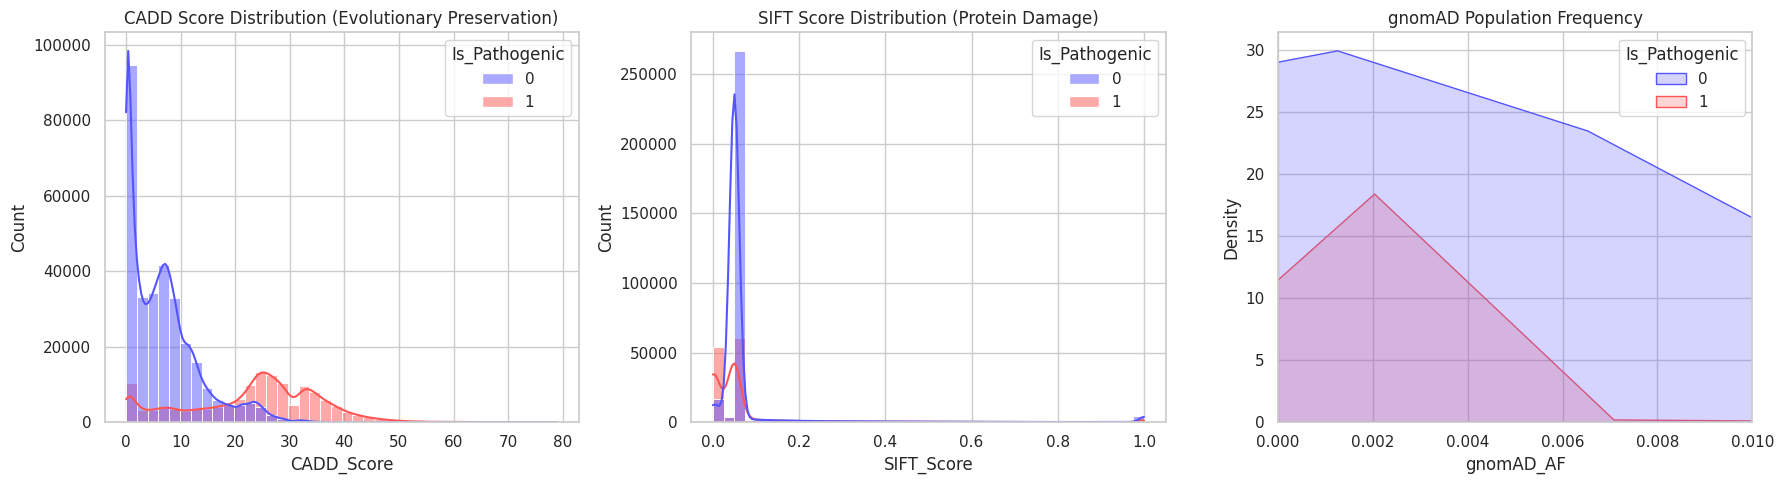


--- Phase 4: Correlation Heatmap ---


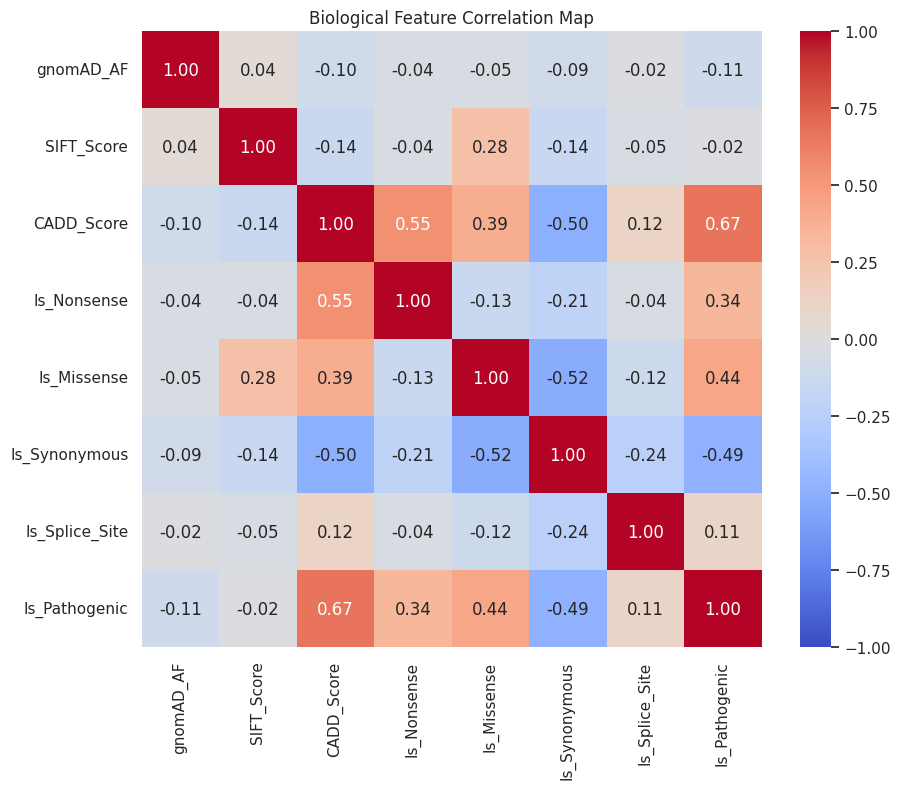

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Phase 1: Loading & Sanity Checks ---")
# Load the dataset you scraped overnight
file_path = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
df = pd.read_csv(file_path)

print(f"Total Variants Scraped: {len(df)}")
print("\nClass Balance (Should be close to 50/50):")
print(df['Is_Pathogenic'].value_counts(normalize=True) * 100)

print("\nMissing Values (Should be 0):")
print(df.isnull().sum())

print("\n--- Phase 2: Biological Feature Verification ---")
# Check how many variants fell back to default values (meaning the API timed out for that specific variant)
default_sift = len(df[df['SIFT_Score'] == 0.05])
default_cadd = len(df[df['CADD_Score'] == 0.0])
print(f"API Timeouts (Defaults used): SIFT={default_sift}, CADD={default_cadd}")

print("\n--- Phase 3: Visualizing the Data ---")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. CADD Score Distribution
# Pathogenic should spike high (usually > 20), Benign should be low
sns.histplot(data=df, x='CADD_Score', hue='Is_Pathogenic', bins=40, kde=True, ax=axes[0], palette='seismic')
axes[0].set_title('CADD Score Distribution (Evolutionary Preservation)')

# 2. SIFT Score Distribution
# Pathogenic should spike near 0.0 (Deleterious), Benign closer to 1.0 (Tolerated)
sns.histplot(data=df, x='SIFT_Score', hue='Is_Pathogenic', bins=40, kde=True, ax=axes[1], palette='seismic')
axes[1].set_title('SIFT Score Distribution (Protein Damage)')

# 3. gnomAD Allele Frequency
# Almost ALL Pathogenic variants should be extremely rare (close to 0)
sns.kdeplot(data=df, x='gnomAD_AF', hue='Is_Pathogenic', fill=True, ax=axes[2], palette='seismic')
axes[2].set_title('gnomAD Population Frequency')
axes[2].set_xlim(0, 0.01) # Zoom in on the rare variants

plt.tight_layout()
plt.show()

print("\n--- Phase 4: Correlation Heatmap ---")
# Let's see which features are most strongly correlated with being Pathogenic
plt.figure(figsize=(10, 8))
# Drop the Variant_ID string column so we can do pure math
correlation_matrix = df.drop(columns=['Variant_ID']).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Biological Feature Correlation Map')
plt.show()

In [4]:
len(df)

447459

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import time

print("--- Phase 1: Loading the Massive Dataset ---")
# Using YOUR new path
file_path = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
df = pd.read_csv(file_path)

# Drop rows where API timed out completely
df_clean = df[df['CADD_Score'] > 0.0].copy()
print(f"Total verified variants for training: {len(df_clean)}\n")

# Separate Clues (X) from Answers (y)
feature_columns = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
X = df_clean[feature_columns]
y = df_clean['Is_Pathogenic']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# MODEL 1: RANDOM FOREST
# ==========================================
print("--- Phase 2: Training Random Forest ---")
start_time = time.time()
# n_jobs=-1 uses all CPU cores to handle the 440k rows fast!
# class_weight='balanced' fixes your 70/30 Benign/Pathogenic split
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

print("Testing Random Forest...")
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"RF Accuracy: {rf_acc * 100:.2f}% (Trained in {rf_time:.1f} seconds)\n")

# ==========================================
# MODEL 2: ADABOOST
# ==========================================
print("--- Phase 3: Training AdaBoost ---")
start_time = time.time()
# AdaBoost learns sequentially, so it might take a minute or two on 440k rows!
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
ada_time = time.time() - start_time

print("Testing AdaBoost...")
ada_pred = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, ada_pred)
print(f"AdaBoost Accuracy: {ada_acc * 100:.2f}% (Trained in {ada_time:.1f} seconds)\n")

# ==========================================
# PHASE 4: THE SHOWDOWN & EXPORT
# ==========================================
print("--- Phase 4: Detailed Showdown ---")
print("RANDOM FOREST REPORT:")
print(classification_report(y_test, rf_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

print("-" * 50)
print("ADABOOST REPORT:")
print(classification_report(y_test, ada_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

# Save both brains
joblib.dump(rf_model, "genomex_rf_model.pkl")
joblib.dump(ada_model, "genomex_adaboost_model.pkl")

print("\nSUCCESS: Both models trained and saved!")
print("Files created: 'genomex_rf_model.pkl' and 'genomex_adaboost_model.pkl'")

--- Phase 1: Loading the Massive Dataset ---
Total verified variants for training: 445519

--- Phase 2: Training Random Forest ---
Testing Random Forest...
RF Accuracy: 87.24% (Trained in 34.9 seconds)

--- Phase 3: Training AdaBoost ---
Testing AdaBoost...
AdaBoost Accuracy: 87.70% (Trained in 14.4 seconds)

--- Phase 4: Detailed Showdown ---
RANDOM FOREST REPORT:
                precision    recall  f1-score   support

    Benign (0)       0.89      0.93      0.91     62085
Pathogenic (1)       0.81      0.75      0.78     27019

      accuracy                           0.87     89104
     macro avg       0.85      0.84      0.85     89104
  weighted avg       0.87      0.87      0.87     89104

--------------------------------------------------
ADABOOST REPORT:
                precision    recall  f1-score   support

    Benign (0)       0.89      0.94      0.91     62085
Pathogenic (1)       0.85      0.73      0.78     27019

      accuracy                           0.88     89104

In [15]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import joblib

print("--- Phase 1: Loading the Massive Dataset ---")
file_path = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
df = pd.read_csv(file_path)

# Drop rows where API timed out completely
df_clean = df[df['CADD_Score'] > 0.0].copy()
print(f"Total verified variants for training: {len(df_clean)}\n")

# Separate Clues (X) from Answers (y)
feature_columns = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
X = df_clean[feature_columns]
y = df_clean['Is_Pathogenic']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate exact weights for the training data based on the 70/30 imbalance
print("Computing sample weights to force the AI to respect Pathogenic variants...")
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ==========================================
# MODEL 1: RANDOM FOREST
# ==========================================
print("\n--- Phase 2: Training Random Forest (Strictly Weighted) ---")
start_time = time.time()
# n_jobs=-1 uses all CPU cores
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Pass the weights directly into the data fitting step
rf_model.fit(X_train, y_train, sample_weight=weights)
rf_time = time.time() - start_time

print("Testing Random Forest...")
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"RF Accuracy: {rf_acc * 100:.2f}% (Trained in {rf_time:.1f} seconds)\n")

# ==========================================
# MODEL 2: ADABOOST
# ==========================================
print("--- Phase 3: Training AdaBoost (Strictly Weighted) ---")
start_time = time.time()
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# AdaBoost now explicitly knows Pathogenic rows carry heavier mathematical weight
ada_model.fit(X_train, y_train, sample_weight=weights)
ada_time = time.time() - start_time

print("Testing AdaBoost...")
ada_pred = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, ada_pred)
print(f"AdaBoost Accuracy: {ada_acc * 100:.2f}% (Trained in {ada_time:.1f} seconds)\n")

# ==========================================
# PHASE 4: THE SHOWDOWN & EXPORT
# ==========================================
print("--- Phase 4: Detailed Showdown ---")
print("RANDOM FOREST REPORT:")
print(classification_report(y_test, rf_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

print("-" * 50)
print("ADABOOST REPORT:")
print(classification_report(y_test, ada_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

# Save both brains
joblib.dump(rf_model, "genomex_rf_model.pkl")
joblib.dump(ada_model, "genomex_adaboost_model.pkl")

print("\nSUCCESS: Both strictly weighted models trained and saved!")
print("Files created: 'genomex_rf_model.pkl' and 'genomex_adaboost_model.pkl'")

--- Phase 1: Loading the Massive Dataset ---
Total verified variants for training: 445519

Computing sample weights to force the AI to respect Pathogenic variants...

--- Phase 2: Training Random Forest (Strictly Weighted) ---
Testing Random Forest...
RF Accuracy: 87.24% (Trained in 35.7 seconds)

--- Phase 3: Training AdaBoost (Strictly Weighted) ---
Testing AdaBoost...
AdaBoost Accuracy: 87.46% (Trained in 14.8 seconds)

--- Phase 4: Detailed Showdown ---
RANDOM FOREST REPORT:
                precision    recall  f1-score   support

    Benign (0)       0.89      0.93      0.91     62085
Pathogenic (1)       0.81      0.75      0.78     27019

      accuracy                           0.87     89104
     macro avg       0.85      0.84      0.85     89104
  weighted avg       0.87      0.87      0.87     89104

--------------------------------------------------
ADABOOST REPORT:
                precision    recall  f1-score   support

    Benign (0)       0.93      0.89      0.91     62

In [10]:
!pip install xgboost catboost scikit-learn pandas -q

In [11]:
!pip install xgboost catboost scikit-learn pandas -q

import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("=== PART 1: THE BASELINE (UNWEIGHTED) ===")

# 1. Load the Data
file_path = '/kaggle/input/datasets/competitiveracist/enriched-clinvar/massive_enriched_dataset.csv'
df = pd.read_csv(file_path)
df_clean = df[df['CADD_Score'] > 0.0].copy()

feature_columns = ['gnomAD_AF', 'SIFT_Score', 'CADD_Score', 'Is_Nonsense', 'Is_Missense', 'Is_Synonymous', 'Is_Splice_Site']
X = df_clean[feature_columns]
y = df_clean['Is_Pathogenic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Unweighted XGBoost
print("\nTraining Baseline XGBoost...")
start_time = time.time()
# n_jobs=-1 uses all CPU cores
xgb_unweighted = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb_unweighted.fit(X_train, y_train)
xgb_time = time.time() - start_time

# 3. Train Unweighted CatBoost
print("Training Baseline CatBoost...")
start_time = time.time()
# verbose=0 stops it from printing 200 lines of loading text
cat_unweighted = CatBoostClassifier(iterations=200, random_state=42, thread_count=-1, verbose=0)
cat_unweighted.fit(X_train, y_train)
cat_time = time.time() - start_time

# 4. Generate the Reports
print("\n" + "="*50)
print(f"UNWEIGHTED XGBOOST REPORT (Trained in {xgb_time:.1f}s)")
print("="*50)
xgb_pred = xgb_unweighted.predict(X_test)
print(classification_report(y_test, xgb_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

print("\n" + "="*50)
print(f"UNWEIGHTED CATBOOST REPORT (Trained in {cat_time:.1f}s)")
print("="*50)
cat_pred = cat_unweighted.predict(X_test)
print(classification_report(y_test, cat_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

=== PART 1: THE BASELINE (UNWEIGHTED) ===

Training Baseline XGBoost...
Training Baseline CatBoost...

UNWEIGHTED XGBOOST REPORT (Trained in 2.2s)
                precision    recall  f1-score   support

    Benign (0)       0.91      0.94      0.92     62085
Pathogenic (1)       0.85      0.78      0.81     27019

      accuracy                           0.89     89104
     macro avg       0.88      0.86      0.87     89104
  weighted avg       0.89      0.89      0.89     89104


UNWEIGHTED CATBOOST REPORT (Trained in 7.8s)
                precision    recall  f1-score   support

    Benign (0)       0.91      0.94      0.92     62085
Pathogenic (1)       0.85      0.78      0.81     27019

      accuracy                           0.89     89104
     macro avg       0.88      0.86      0.87     89104
  weighted avg       0.89      0.89      0.89     89104



In [14]:
import joblib

print("=== PART 2: THE OPTIMIZED (WEIGHTED) ===")

# Calculate the exact imbalance ratio for XGBoost
# (Number of Benign rows / Number of Pathogenic rows)
ratio = float(len(y_train[y_train == 0])) / len(y_train[y_train == 1])
print(f"Detected Imbalance Ratio: 1 Pathogenic for every {ratio:.2f} Benign variants.\n")

# 1. Train Weighted XGBoost
print("Training Weighted XGBoost...")
start_time = time.time()
xgb_weighted = XGBClassifier(
    n_estimators=200, 
    random_state=42, 
    n_jobs=-1,
    scale_pos_weight=ratio  # <-- THE MAGIC FIX
)
xgb_weighted.fit(X_train, y_train)
xgb_w_time = time.time() - start_time

# 2. Train Weighted CatBoost
print("Training Weighted CatBoost...")
start_time = time.time()
cat_weighted = CatBoostClassifier(
    iterations=200, 
    random_state=42, 
    thread_count=-1, 
    verbose=0,
    auto_class_weights='Balanced' # <-- THE MAGIC FIX
)
cat_weighted.fit(X_train, y_train)
cat_w_time = time.time() - start_time

# 3. Generate the Reports
print("\n" + "="*50)
print(f"WEIGHTED XGBOOST REPORT (Trained in {xgb_w_time:.1f}s)")
print("="*50)
xgb_w_pred = xgb_weighted.predict(X_test)
print(classification_report(y_test, xgb_w_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

print("\n" + "="*50)
print(f"WEIGHTED CATBOOST REPORT (Trained in {cat_w_time:.1f}s)")
print("="*50)
cat_w_pred = cat_weighted.predict(X_test)
print(classification_report(y_test, cat_w_pred, target_names=['Benign (0)', 'Pathogenic (1)']))

# 4. Save the ultimate winners
joblib.dump(xgb_weighted, "genomex_xgboost_final.pkl")
joblib.dump(cat_weighted, "genomex_catboost_final.pkl")
print("\n SUCCESS: Final models exported for the Next.js/FastAPI app!")

=== PART 2: THE OPTIMIZED (WEIGHTED) ===
Detected Imbalance Ratio: 1 Pathogenic for every 2.26 Benign variants.

Training Weighted XGBoost...
Training Weighted CatBoost...

WEIGHTED XGBOOST REPORT (Trained in 2.1s)
                precision    recall  f1-score   support

    Benign (0)       0.92      0.91      0.92     62085
Pathogenic (1)       0.80      0.83      0.81     27019

      accuracy                           0.88     89104
     macro avg       0.86      0.87      0.86     89104
  weighted avg       0.88      0.88      0.88     89104


WEIGHTED CATBOOST REPORT (Trained in 8.0s)
                precision    recall  f1-score   support

    Benign (0)       0.92      0.91      0.92     62085
Pathogenic (1)       0.80      0.83      0.81     27019

      accuracy                           0.88     89104
     macro avg       0.86      0.87      0.86     89104
  weighted avg       0.88      0.88      0.88     89104


 SUCCESS: Final models exported for the Next.js/FastAPI app!
